[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HisameOgasahara/tmp_diffsynth_practive/blob/main/anima_minimal_colab.ipynb)

# Minimal Anima T2I — extracted DiffSynth path

ComfyUI / Diffusers / DiffSynth를 설치하거나 별도 git clone하지 않습니다. 이 저장소의 최소 모델 정의와 일반 Python 라이브러리만 사용합니다. 모델 가중치는 공개 Hugging Face `circlestone-labs/Anima`에서 인증 없이 받습니다.


In [1]:
# 1. Colab 기본 torch / transformers / huggingface_hub / Pillow는 그대로 사용
!pip -q install safetensors einops sentencepiece tqdm


In [2]:
# 2. 이 실습 저장소만 clone / 최신 코드 강제 반영
from pathlib import Path
import importlib, subprocess, sys, torch

REPO = 'https://github.com/HisameOgasahara/tmp_diffsynth_practive.git'
ROOT = Path('/content/tmp_diffsynth_practive')
if not ROOT.exists():
    subprocess.run(['git', 'clone', '--depth', '1', REPO, str(ROOT)], check=True)
else:
    subprocess.run(['git', '-C', str(ROOT), 'fetch', 'origin', 'main'], check=True)
    subprocess.run(['git', '-C', str(ROOT), 'reset', '--hard', 'origin/main'], check=True)

SRC = str(ROOT / 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

if 'anima_core.model_cache' in sys.modules:
    sys.modules['anima_core.model_cache'].clear_model_cache()

for name in list(sys.modules):
    if name == 'anima_core' or name.startswith('anima_core.'):
        del sys.modules[name]
importlib.invalidate_caches()

commit = subprocess.check_output(['git', '-C', str(ROOT), 'rev-parse', '--short', 'HEAD'], text=True).strip()
print('commit:', commit)
print(torch.__version__, torch.cuda.get_device_name() if torch.cuda.is_available() else 'NO CUDA')


commit: a80872f
2.11.0+cu128 Tesla T4


In [10]:
# 3. Baseline 생성값 — 수정 후 JSON으로 저장
import json
from pathlib import Path

PROMPT = 'shirakawa yuina, @WFS, blue headgear, platinum blonde hair, 1girl, solo, upper body, blue capelet, white uniform shirt, white pleated skirt, white pantyhose, sunlight, soft lighting, gentle breeze, floating particles, from side, looking up, from side, blurry, depth of field, sunlight, vibrant colors, wallpaper' # @param {type:'string'}
NEGATIVE_PROMPT = 'worst quality, low quality, score_1, score_2, score_3, blurry, jpeg artifacts' # @param {type:'string'}
SEED = 1113280783077048 # @param {type:'integer'}
RANDOM_SEED = True # @param {type:'boolean'}
STEPS = 30 # @param {type:'integer'}
CFG = 4.0 # @param {type:'number'}
WIDTH = 1216 # @param {type:'integer'}
HEIGHT = 832 # @param {type:'integer'}
DENOISE = 1.0 # @param {type:'number'}
SHIFT = 3.0 # @param {type:'number'}
USE_TOKEN_WEIGHTS = True # @param {type:'boolean'}
USE_MODEL_CACHE = True # @param {type:'boolean'}
LOG_LEVEL = 'INFO' # @param ['DEBUG', 'INFO', 'WARNING', 'ERROR']
SHOW_PROGRESS = True # @param {type:'boolean'}
ENABLE_PROFILER = False # @param {type:'boolean'}
PROFILE_STAGES = 'sample_euler' # @param {type:'string'}
PROFILE_OUTPUT_DIR = '/content/anima_profiles' # @param {type:'string'}
PROFILE_WAIT = 0 # @param {type:'integer'}
PROFILE_WARMUP = 1 # @param {type:'integer'}
PROFILE_ACTIVE = 3 # @param {type:'integer'}
PROFILE_RECORD_SHAPES = False # @param {type:'boolean'}
PROFILE_MEMORY = False # @param {type:'boolean'}
PROFILE_WITH_STACK = False # @param {type:'boolean'}
PROFILE_ROW_LIMIT = 20 # @param {type:'integer'}

CONFIG_PATH = Path('/content/anima_minimal_config.json')
config = {
    'prompt': PROMPT,
    'negative_prompt': NEGATIVE_PROMPT,
    'seed': int(SEED),
    'random_seed': RANDOM_SEED,
    'steps': int(STEPS),
    'cfg': float(CFG),
    'width': int(WIDTH),
    'height': int(HEIGHT),
    'denoise': float(DENOISE),
    'shift': float(SHIFT),
    'device': 'cuda',
    'dtype': 'float16',
    'lora_path': '',
    'lora_scale': 1.0,
    'use_token_weights': USE_TOKEN_WEIGHTS,
    'use_model_cache': USE_MODEL_CACHE,
    'logging': {'level': LOG_LEVEL, 'progress': SHOW_PROGRESS},
    'profiler': {
        'enabled': ENABLE_PROFILER,
        'stages': [name.strip() for name in PROFILE_STAGES.split(',') if name.strip()],
        'output_dir': PROFILE_OUTPUT_DIR,
        'wait': PROFILE_WAIT, 'warmup': PROFILE_WARMUP, 'active': PROFILE_ACTIVE,
        'record_shapes': PROFILE_RECORD_SHAPES,
        'profile_memory': PROFILE_MEMORY,
        'with_stack': PROFILE_WITH_STACK,
        'row_limit': PROFILE_ROW_LIMIT,
    },
}
CONFIG_PATH.write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding='utf-8')
print(CONFIG_PATH)
print(json.dumps(config, ensure_ascii=False, indent=2))


/content/anima_minimal_config.json
{
  "prompt": "shirakawa yuina, @WFS, blue headgear, platinum blonde hair, 1girl, solo, upper body, blue capelet, white uniform shirt, white pleated skirt, white pantyhose, sunlight, soft lighting, gentle breeze, floating particles, from side, looking up, from side, blurry, depth of field, sunlight, vibrant colors, wallpaper",
  "negative_prompt": "worst quality, low quality, score_1, score_2, score_3, blurry, jpeg artifacts",
  "seed": 1113280783077048,
  "random_seed": true,
  "steps": 30,
  "cfg": 4.0,
  "width": 1216,
  "height": 832,
  "denoise": 1.0,
  "shift": 3.0,
  "device": "cuda",
  "dtype": "float16",
  "lora_path": "",
  "lora_scale": 1.0,
  "use_token_weights": true,
  "use_model_cache": true,
  "logging": {
    "level": "INFO",
    "progress": true
  },
  "profiler": {
    "enabled": false,
    "stages": [
      "sample_euler"
    ],
    "output_dir": "/content/anima_profiles",
    "wait": 0,
    "warmup": 1,
    "active": 3,
    "recor

In [11]:
# 4. 공개 HF에서 Anima 가중치 미리 받기 — 선택 셀, token/auth 없음
import json
from pathlib import Path
from anima_core.runtime import configure_diagnostics, download_weights
configure_diagnostics(json.loads(Path('/content/anima_minimal_config.json').read_text(encoding='utf-8')))
download_weights()
print('가중치 캐시 준비 완료')


08:06:09 | INFO | 모델 가중치 다운로드/캐시 확인 시작
08:06:09 | INFO | dit 가중치 확인: split_files/diffusion_models/anima-base-v1.0.safetensors
08:06:09 | INFO | dit 가중치 준비 완료
08:06:09 | INFO | text_encoder 가중치 확인: split_files/text_encoders/qwen_3_06b_base.safetensors
08:06:09 | INFO | text_encoder 가중치 준비 완료
08:06:09 | INFO | vae 가중치 확인: split_files/vae/qwen_image_vae.safetensors
08:06:09 | INFO | vae 가중치 준비 완료
08:06:09 | INFO | 모델 가중치 다운로드/캐시 확인 완료 (경과 0.01초)
가중치 캐시 준비 완료


## 선택: Anima LoRA 파일 준비

3번 셀 다음에 실행하세요. 로컬/Google Drive 파일 경로 또는 HF 저장소와 파일명을 입력합니다. `LORA_PATH`가 비어 있으면 기본 T2I로 생성합니다. LoRA 적용은 `src/anima_core/lora.py`에서 처리하며, 6번 셀에서 text adapter 계산 전에 가중치에 합칩니다.

표준 Linear LoRA의 `lora_A/B[.default].weight`와 `lora_down/up.weight`, 레이어별 `alpha`를 지원합니다. 다른 모델용 LoRA, DoRA/LyCORIS, fused QKV 전용 가중치는 지원하지 않습니다. LoRA 설명에 필요한 트리거 단어가 있으면 3번 셀의 prompt에 넣으세요.


In [12]:
# 4-1. 선택: LoRA 다운로드/경로 설정 (적용 로직은 Python 모듈에 있음)
import json
from pathlib import Path

LORA_SOURCE = 'google_drive' # @param ['local', 'google_drive', 'hugging_face']
LORA_PATH = '/content/drive/MyDrive/1/self_made/lora_400.safetensors' # @param {type:'string'}
LORA_SCALE = 0.9 # @param {type:'number'}
HF_LORA_REPO = '' # @param {type:'string'}
HF_LORA_FILENAME = '' # @param {type:'string'}
HF_LORA_REVISION = 'main' # @param {type:'string'}

if LORA_SOURCE == 'google_drive':
    from google.colab import drive
    drive.mount('/content/drive')
elif LORA_SOURCE == 'hugging_face':
    from huggingface_hub import hf_hub_download
    LORA_PATH = hf_hub_download(repo_id=HF_LORA_REPO, filename=HF_LORA_FILENAME, revision=HF_LORA_REVISION)

CONFIG_PATH = Path('/content/anima_minimal_config.json')
config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
config['lora_path'] = LORA_PATH.strip()
config['lora_scale'] = float(LORA_SCALE)
CONFIG_PATH.write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding='utf-8')
print('LoRA:', config['lora_path'] or '사용 안 함', 'scale:', config['lora_scale'])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LoRA: /content/drive/MyDrive/1/self_made/lora_400.safetensors scale: 1.0


In [13]:
# 5. Text Encoder -> positive / negative conditioning 저장
import gc, json, torch
from pathlib import Path
from anima_core.runtime import configure_diagnostics, download_weights, load_tokenizers, encode_prompt
from anima_core.model_cache import use_text_encoder

CONFIG_PATH = Path('/content/anima_minimal_config.json')
if not CONFIG_PATH.exists():
    raise RuntimeError('3번 셀을 먼저 실행해서 생성 설정 JSON을 만들어주세요.')
config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
configure_diagnostics(config)
device = config['device']
dtype = getattr(torch, config['dtype'])
weights = download_weights()

qwen_tokenizer, t5_tokenizer = load_tokenizers()
with use_text_encoder(weights['text_encoder'], device, dtype, enabled=config.get('use_model_cache', False)) as text_encoder:
    positive_raw, positive_t5, positive_weights = encode_prompt(text_encoder, qwen_tokenizer, t5_tokenizer, config['prompt'], device, dtype, use_token_weights=config.get('use_token_weights', False), return_token_weights=True)
    negative_raw, negative_t5, negative_weights = encode_prompt(text_encoder, qwen_tokenizer, t5_tokenizer, config['negative_prompt'], device, dtype, use_token_weights=config.get('use_token_weights', False), return_token_weights=True)

CONDITIONING_PATH = Path('/content/anima_conditioning.pt')
torch.save({
    'positive_raw': positive_raw.cpu(),
    'positive_t5': positive_t5.cpu(),
    'positive_weights': positive_weights.cpu(),
    'negative_raw': negative_raw.cpu(),
    'negative_t5': negative_t5.cpu(),
    'negative_weights': negative_weights.cpu(),
}, CONDITIONING_PATH)

del text_encoder, positive_raw, positive_t5, negative_raw, negative_t5, positive_weights, negative_weights
gc.collect(); torch.cuda.empty_cache()
print('conditioning:', CONDITIONING_PATH)


08:06:19 | INFO | 모델 가중치 다운로드/캐시 확인 시작
08:06:19 | INFO | dit 가중치 확인: split_files/diffusion_models/anima-base-v1.0.safetensors
08:06:19 | INFO | dit 가중치 준비 완료
08:06:19 | INFO | text_encoder 가중치 확인: split_files/text_encoders/qwen_3_06b_base.safetensors
08:06:19 | INFO | text_encoder 가중치 준비 완료
08:06:19 | INFO | vae 가중치 확인: split_files/vae/qwen_image_vae.safetensors
08:06:19 | INFO | vae 가중치 준비 완료
08:06:19 | INFO | 모델 가중치 다운로드/캐시 확인 완료 (경과 0.01초)
08:06:19 | INFO | Qwen/T5 tokenizer 로딩 시작
08:06:20 | INFO | Qwen/T5 tokenizer 로딩 완료 (경과 1.27초)
08:06:20 | INFO | text_encoder 캐시 hit: 파일 재로딩 없이 재사용
08:06:20 | INFO | 캐시 모델 장치 이동 시작
08:06:20 | INFO | ZImageTextEncoder -> cuda
08:06:21 | INFO | 캐시 모델 장치 이동 완료 (경과 0.37초)
08:06:21 | INFO | Qwen prompt encoding 시작
08:06:21 | INFO | Qwen prompt encoding 완료 (경과 0.09초)
08:06:21 | INFO | Qwen prompt encoding 시작
08:06:21 | INFO | Qwen prompt encoding 완료 (경과 0.08초)
08:06:21 | INFO | 캐시 모델 장치 이동 시작
08:06:21 | INFO | ZImageTextEncoder -> cpu
08:06:22 | INFO | 

In [14]:
# 6. Anima text adapter + DiT + CFG + Euler -> latent 저장
import gc, json, torch
import secrets
from pathlib import Path
from anima_core.runtime import configure_diagnostics, download_weights, adapt_conditioning, sample_euler
from anima_core.model_cache import use_dit

CONFIG_PATH = Path('/content/anima_minimal_config.json')
CONDITIONING_PATH = Path('/content/anima_conditioning.pt')
if not CONFIG_PATH.exists():
    raise RuntimeError('3번 셀을 먼저 실행해서 생성 설정 JSON을 만들어주세요.')
if not CONDITIONING_PATH.exists():
    raise RuntimeError('5번 셀을 먼저 실행해서 conditioning 파일을 만들어주세요.')

config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
configure_diagnostics(config)
device = config['device']
dtype = getattr(torch, config['dtype'])
weights = download_weights()
conditioning = torch.load(CONDITIONING_PATH, map_location='cpu')
seed = secrets.randbelow(torch.iinfo(torch.int64).max) if config.get('random_seed', False) else config['seed']
print('생성 시드:', seed)

with use_dit(
    weights['dit'], device, dtype,
    enabled=config.get('use_model_cache', False),
    lora_path=config.get('lora_path'),
    lora_scale=config.get('lora_scale', 1.0),
) as dit:
    positive = adapt_conditioning(
        dit,
        conditioning['positive_raw'].to(device=device, dtype=dtype),
        conditioning['positive_t5'].to(device),
        t5_weights=conditioning['positive_weights'].to(device=device, dtype=dtype) if 'positive_weights' in conditioning else None,
    )
    negative = adapt_conditioning(
        dit,
        conditioning['negative_raw'].to(device=device, dtype=dtype),
        conditioning['negative_t5'].to(device),
        t5_weights=conditioning['negative_weights'].to(device=device, dtype=dtype) if 'negative_weights' in conditioning else None,
    )

    latents = sample_euler(
        dit,
        positive,
        negative,
        config['height'],
        config['width'],
        seed,
        config['steps'],
        config['cfg'],
        denoise=config['denoise'],
        shift=config['shift'],
        device=device,
        dtype=dtype,
    )

    LATENTS_PATH = Path('/content/anima_latents.pt')
    torch.save(latents.cpu(), LATENTS_PATH)
del dit, positive, negative, latents, conditioning
gc.collect(); torch.cuda.empty_cache()
print('latents:', LATENTS_PATH)


08:06:22 | INFO | 모델 가중치 다운로드/캐시 확인 시작
08:06:22 | INFO | dit 가중치 확인: split_files/diffusion_models/anima-base-v1.0.safetensors
08:06:22 | INFO | dit 가중치 준비 완료
08:06:22 | INFO | text_encoder 가중치 확인: split_files/text_encoders/qwen_3_06b_base.safetensors
08:06:22 | INFO | text_encoder 가중치 준비 완료
08:06:22 | INFO | vae 가중치 확인: split_files/vae/qwen_image_vae.safetensors
08:06:22 | INFO | vae 가중치 준비 완료
08:06:22 | INFO | 모델 가중치 다운로드/캐시 확인 완료 (경과 0.01초)
생성 시드: 852203348695277232
08:06:22 | INFO | dit 캐시 hit: 파일 재로딩 없이 재사용
08:06:22 | INFO | 캐시 모델 장치 이동 시작
08:06:22 | INFO | AnimaDiT -> cuda
08:06:23 | INFO | 캐시 모델 장치 이동 완료 (경과 1.46초)
08:06:23 | INFO | Anima text adapter conditioning 시작
08:06:23 | INFO | Anima text adapter conditioning 완료 (경과 0.01초)
08:06:23 | INFO | Anima text adapter conditioning 시작
08:06:23 | INFO | Anima text adapter conditioning 완료 (경과 0.01초)
08:06:23 | INFO | Euler 이미지 생성 시작
08:06:23 | INFO | 생성 설정: 1216x832, steps=30, CFG=4.0, seed=852203348695277232


Euler 생성:   0%|          | 0/30 [00:00<?, ?it/s]

08:07:55 | INFO | Euler 이미지 생성 완료 (경과 91.29초)
08:07:55 | INFO | 캐시 모델 장치 이동 시작
08:07:55 | INFO | AnimaDiT -> cpu
08:07:57 | INFO | 캐시 모델 장치 이동 완료 (경과 2.37초)
08:07:57 | INFO | dit: CPU RAM에 보관
latents: /content/anima_latents.pt


08:07:57 | INFO | 모델 가중치 다운로드/캐시 확인 시작
08:07:57 | INFO | dit 가중치 확인: split_files/diffusion_models/anima-base-v1.0.safetensors
08:07:57 | INFO | dit 가중치 준비 완료
08:07:57 | INFO | text_encoder 가중치 확인: split_files/text_encoders/qwen_3_06b_base.safetensors
08:07:57 | INFO | text_encoder 가중치 준비 완료
08:07:57 | INFO | vae 가중치 확인: split_files/vae/qwen_image_vae.safetensors
08:07:57 | INFO | vae 가중치 준비 완료
08:07:57 | INFO | 모델 가중치 다운로드/캐시 확인 완료 (경과 0.01초)
08:07:57 | INFO | vae 캐시 hit: 파일 재로딩 없이 재사용
08:07:57 | INFO | 캐시 모델 장치 이동 시작
08:07:57 | INFO | WanVideoVAE -> cuda
08:07:58 | INFO | 캐시 모델 장치 이동 완료 (경과 0.08초)
08:07:58 | INFO | VAE 이미지 디코딩 시작
08:07:59 | INFO | VAE 이미지 디코딩 완료 (경과 1.10초)
08:07:59 | INFO | 캐시 모델 장치 이동 시작
08:07:59 | INFO | WanVideoVAE -> cpu
08:07:59 | INFO | 캐시 모델 장치 이동 완료 (경과 0.08초)
08:07:59 | INFO | vae: CPU RAM에 보관


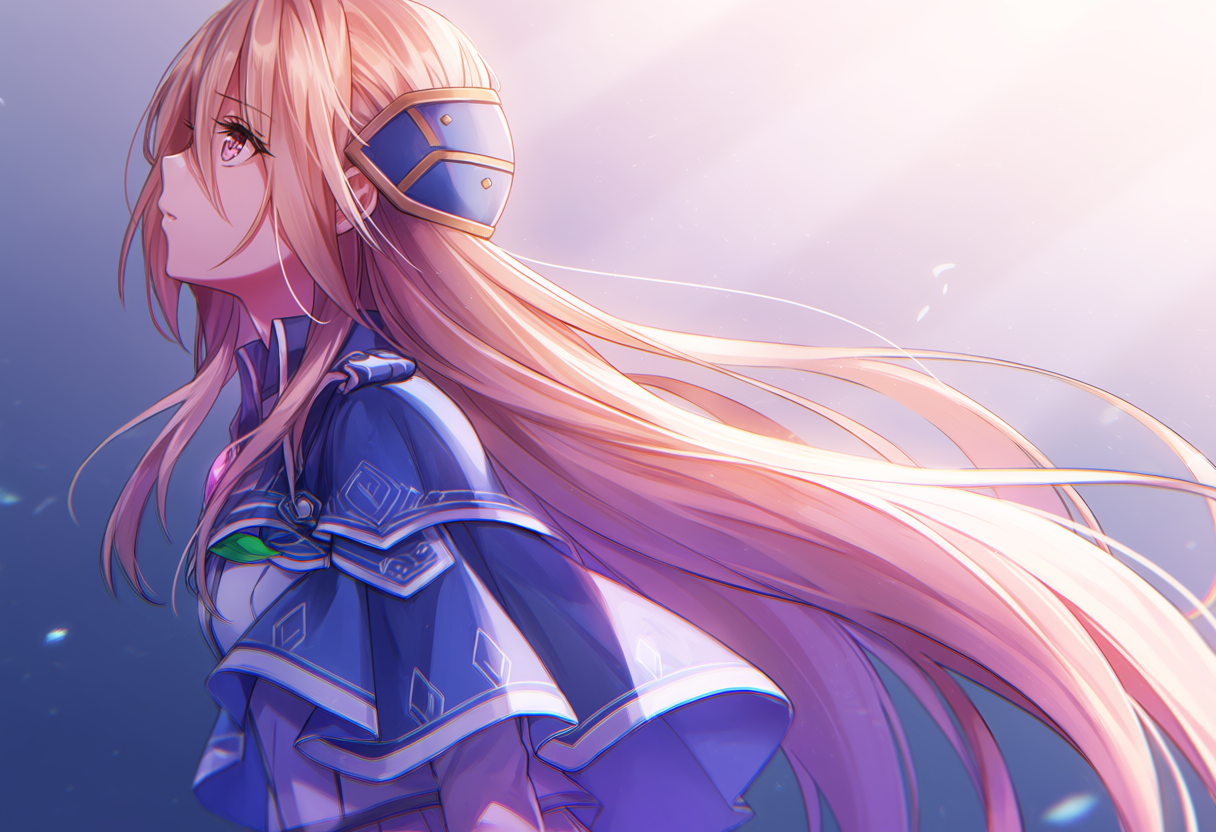

/content/anima_minimal.png


In [15]:
# 7. VAE decode -> PNG
import gc, json, torch
from pathlib import Path
from IPython.display import display
from anima_core.runtime import configure_diagnostics, download_weights, decode_image
from anima_core.model_cache import use_vae

CONFIG_PATH = Path('/content/anima_minimal_config.json')
LATENTS_PATH = Path('/content/anima_latents.pt')
if not CONFIG_PATH.exists():
    raise RuntimeError('3번 셀을 먼저 실행해서 생성 설정 JSON을 만들어주세요.')
if not LATENTS_PATH.exists():
    raise RuntimeError('6번 셀을 먼저 실행해서 latent 파일을 만들어주세요.')

config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
configure_diagnostics(config)
device = config['device']
dtype = getattr(torch, config['dtype'])
weights = download_weights()
latents = torch.load(LATENTS_PATH, map_location='cpu').to(device=device, dtype=dtype)

with use_vae(weights['vae'], device, dtype, enabled=config.get('use_model_cache', False)) as vae:
    image = decode_image(vae, latents, device)
OUTPUT = Path('/content/anima_minimal.png')
image.save(OUTPUT)
display(image)
print(OUTPUT)

del vae, latents
gc.collect(); torch.cuda.empty_cache()
